In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Que no haya límite en número de columnas
pd.set_option('display.max_columns', None)

# Ajustes opcionales para que no quiebre líneas
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Funciones

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors

# Estilo seaborn para la figura
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_metric_grid_all(
        df_full,
        df_only_coreset,
        df_latent,
        df_latent_ft,
        df_TDColer=pd.DataFrame(),
        spaces=('original', 'latent'),
        max_ipc=100,
        metric='test_balanced',
        methods=('k-means', 'k-center', 'ag'),
        models=None,
        x_label='Instances Per Class',
        y_label='Test balanced',
        name_savefig='figura.png'
    ):
    """
    Grid dinámico metric vs IPC:
      • Filas → cada modelo de `models`.
      • Columnas → bloques por espacio (cada bloque = len(methods) columnas).
    Fondo de cada bloque coloreado según espacio (original / latent).
    Dentro de cada celda:
      - Curvas media±std de cada técnica (Original, CorVAE, TDColer).
      - Línea base full-data.
      - Cuadro con valor Full-data y máximo de CorVAE.
    """

    

    # 1) Unir DataFrames con columna 'space' y 'technique'
    df_list = []
    for space in spaces:
        d_latent = df_latent[df_latent['space'] == space]
        d_tdcol  = df_TDColer[df_TDColer['space'] == space] if not df_TDColer.empty else pd.DataFrame()
        for src, tech in [
            (df_only_coreset, 'Original'),
            (d_latent,       'CorVAE'),
            #(df_latent_ft,  'latent_ft'),
            (d_tdcol,        'TDColer'),
        ]:
            if src.empty:
                continue
            tmp = src.copy()
            tmp['technique'] = tech
            tmp['space']     = space
            df_list.append(tmp)

    df_all = pd.concat(df_list, ignore_index=True)
    df_all = df_all[df_all['IPC'] <= max_ipc]

    # 2) Preparo figura y ejes
    n_rows = len(models)
    n_cols = len(spaces) * len(methods)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4*n_cols, 3*n_rows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(n_rows, n_cols)

    # Paleta fija para líneas
    tech_colors = {
        'Original': 'C0',
        'CorVAE':   'C2',
        'TDColer':  'C4',
    }
    baseline_color = 'gray'

    # Paleta pastel para fondos de espacios
    bg_palette = sns.color_palette("pastel", len(spaces))
    bg_colors  = dict(zip(spaces, bg_palette))

    # 3) Rellenar cada subplot
    for i, model in enumerate(models):
        for k, space in enumerate(spaces):
            for j, method in enumerate(methods):
                col = k * len(methods) + j
                ax = axes[i, col]

                # Sombreado de fondo según espacio
                rgba = mcolors.to_rgba(bg_colors[space], alpha=0.1)
                ax.set_facecolor(rgba)

                sub = df_all[
                    (df_all['model']  == model) &
                    (df_all['method'] == method) &
                    (df_all['space']  == space)
                ]
                if sub.empty:
                    ax.set_visible(False)
                    continue

                ax.set_title(f"{model} – {method}", loc='left', pad=6)

                # Dibujar curvas y calcular máximo de CorVAE
                corvae_max_val = None
                corvae_max_ipc = None
                for tech, color in tech_colors.items():
                    sp = sub[sub['technique'] == tech]
                    if sp.empty:
                        continue
                    #print(sp)
                    grp = sp.groupby('IPC')[metric].agg(['mean','std']).reset_index()
                    ax.plot(grp['IPC'], grp['mean'],
                            marker='o', label=tech, color=color)
                    ax.fill_between(
                        grp['IPC'],
                        grp['mean'] - grp['std'],
                        grp['mean'] + grp['std'],
                        alpha=0.2, color=color
                    )
                    # si es CorVAE, calcular su máximo
                    if tech == 'CorVAE':
                        idx = grp['mean'].idxmax()
                        corvae_max_val = grp.at[idx, 'mean']
                        corvae_max_ipc = grp.at[idx, 'IPC']

                # Línea base full-data
                baseline = df_full[df_full['model'] == model][metric].mean()
                ax.axhline(y=baseline,
                           linestyle='--',
                           color=baseline_color,
                           label='Full-data')

                ax.grid(True, linestyle='--', alpha=0.5)
                ax.set_xlim(0, max_ipc)

    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0.02)

    # Leyenda global (manual, sin solape)
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='o', color=tech_colors['Original'], label='Original'),
        Line2D([0], [0], marker='o', color=tech_colors['CorVAE'],   label='CorVAE'),
        Line2D([0], [0], linestyle='--', color=baseline_color,      label='Full-data'),
    ]

    if 'TDColer' in df_all['technique'].unique():
        legend_elements.append(
            Line2D([0], [0], marker='o', color=tech_colors['TDColer'], label='TDColer')
        )

    # fig.legend(
    #     handles=legend_elements,
    #     loc='upper center',
    #     ncol=len(legend_elements),
    #     title='Técnica',
    #     bbox_to_anchor=(0.5, 1.03),  # sube un poco más la leyenda
    #     fontsize=12,
    #     title_fontsize=13
    # )

    # Ajustar layout para no solapar
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # más espacio arriba
    plt.savefig(name_savefig, dpi=300, bbox_inches='tight')
    plt.show()


In [5]:

def plot_metric_grid(df_random,
                     df_original,
                     df_latent,
                     df_latent_ft,
                     space='original',
                     max_ipc=100,
                     metric='test_balanced',
                     x_label='Instances Per Class',
                     y_label='Test balanced',
                     methods=['k-means',
                              'k-center',
                              'ag'
                              ]):
    """
    Dibuja en una única figura (grid) la curva de `metric` vs IPC
    para cada combinación (método, modelo).  
    Filas → modelos, Columnas → métodos.  
    Dentro de cada celda: las tres técnicas de distilación
    (original, latent, latent_ft) con media ± std, y línea base Full-data.
    """

    df_latent = df_latent[df_latent['space'] == space]
    df_latent_ft = df_latent_ft[df_latent_ft['space'] == space]

    # 1) Concatena solo los tres DataFrames de distilación
    dfs = [
        (df_original.copy(),  'original'),
        (df_latent.copy(),    'latent'),
        (df_latent_ft.copy(), 'latent_ft'),
    ]
    df_list = []
    for df, tech in dfs:
        df['technique'] = tech
        df_list.append(df)
    df_all_init = pd.concat(df_list, ignore_index=True)

    df_all = df_all_init[df_all_init['IPC'] <= max_ipc]

    # 3) Métodos y modelos para el grid
    #methods = sorted([m for m in df_all['method'].unique()
    #                  if m not in ['random', 'Full-data']])
    models  = sorted(df_all['model'].unique())

    # Swap: filas = modelos, columnas = métodos
    n_rows, n_cols = len(models), len(methods)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharex=True, sharey=True)

    # 4) Paleta para las tres técnicas
    palette = {
        'original':  'C0',
        'latent':    'C2',
        'latent_ft': 'C3',
        'TDColer':   'C4',
    }

    # 5) Rellenar cada celda
    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i, j] if n_rows > 1 and n_cols > 1 else (
                 axes[j] if n_rows == 1 else axes[i])
            
            

            sub = df_all[
                (df_all['method'] == method) &
                (df_all['model']  == model)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue

            # Título interno de cada subplot
            ax.set_title(f"{model} – {method}", loc='left', pad=10)

            # Dibujar las curvas de cada técnica
            for tech, color in palette.items():
                sp = sub[sub['technique'] == tech]
                if sp.empty:
                    continue
                grp = (sp
                       .groupby('IPC')[metric]
                       .agg(['mean', 'std'])
                       .reset_index())
                ax.plot(grp['IPC'], grp['mean'],
                        marker='o', label=tech, color=color)
                ax.fill_between(
                    grp['IPC'],
                    grp['mean'] - grp['std'],
                    grp['mean'] + grp['std'],
                    alpha=0.2, color=color
                )

            # Línea base para 'Full-data'
            baseline_df = df_all_init[
                (df_all_init['method'] == 'Full-data') &
                (df_all_init['model']  == model)
            ]
            if not baseline_df.empty:
                baseline_val = baseline_df[metric].mean()
                ax.axhline(
                    y=baseline_val,
                    linestyle='--',
                    color='gray',
                    label='Full-data'
                )

            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_xlim(0, max_ipc)

    # 6) Etiquetas globales de ejes
    # Para Matplotlib >= 3.4 puedes usar:
    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0)

    # 7) Leyenda común arriba
    # Tomamos los handles/labels del último ax válido
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', ncol=len(palette)+1,
               title="Técnica")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Creación del dataset

In [7]:


def rename_rows(df, column, mapping):
    """
    Renombra las filas de un DataFrame para que coincidan con el método.
    """
    df = df.copy()

    # Aplicamos el cambio en el DataFrame
    df[column] = (df[column]
                .replace(mapping)                # reemplaza los que estén en el dict
                #.str.lower()                     # opcional: pasar todo a minúsculas
                )
    return df

def preprocess_baseline(df):
    df = df[['Classifier','Encoder','Data Parse Mode','Distill Method','Distill Space',
             'Output Space','Convert Binary','Cluster Center','N','Score']]
    
    mapping_classifier = {
        'XGBClassifier':       'xgb',
        'MLPClassifier':  'mlp',
        'KNeighborsClassifier':'knn',
        'GaussianNB': 'naive_bayes',
        'LogisticRegression': 'logreg',
    }

    mapping_method = {
        'KMeans':       'k-means',
        'Agglo':  'ag',
    }

    mapping_space = {
        'decoded':       'original',
        'encoded':  'latent',

    }

    df = rename_rows(df, 'Classifier', mapping_classifier)
    df = rename_rows(df, 'Distill Method', mapping_method)
    df = rename_rows(df, 'Output Space', mapping_space)

    df.rename(columns={'N': 'IPC',
                       'Distill Method':'method',
                       'Classifier':'model',
                       'Score':'test_balanced',
                       'Output Space':'space'
                       
                       }, inplace=True)

    df_full = df[
                        (df['Data Parse Mode'] == 'mixed') &
                        (df['method'] == 'Original') &
                        (df['Convert Binary'] == False)
                    ]
    
    df_only_coreset = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'original') &
                        (df['space'] == 'original') &
                        (df['Convert Binary'] == False) &
                        (df['Cluster Center'] == 'centroid') 
                    ]
                    
    df_latent = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF')
                    ]
    df_latent_ft = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF-MultiHead')
                    ]

    df_full = df_full[['model','method','IPC','test_balanced','space']]
    df_only_coreset = df_only_coreset[['model','method','IPC','test_balanced','space']]
    df_latent = df_latent[['model','method','IPC','test_balanced','space']]
    df_latent_ft = df_latent_ft[['model','method','IPC','test_balanced', 'space']]

    return df_full,df_only_coreset,df_latent, df_latent_ft

In [108]:
# Preprocesamiento del dataset de TDColer

df_tdcoler_adult = pd.read_csv('TDCOLER_adult.csv')
df_tdcoler_default = pd.read_csv('TDCOLER_default.csv')

(df_tdcoler_full_adult, df_tdcoler_only_coreset_adult, 
 df_tdcoler_latent_adult, df_tdcoler_latent_ft_adult) = preprocess_baseline(df_tdcoler_adult)

(df_tdcoler_full_default, df_tdcoler_only_coreset_default, 
 df_tdcoler_latent_default, df_tdcoler_latent_ft_default) = preprocess_baseline(df_tdcoler_default)

### Dataset de adult

In [82]:
df_only_coreset_adult = pd.read_csv('../BACKUP/Experiments_A/checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_only_coreset_adult['method'] = df_only_coreset_adult['method'].replace(
     'k_center', 'k-center'
)
df_full_adult = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_adult = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_F/metrics.csv')
df_latent_ft_adult = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_ft_F/metrics.csv')

In [83]:
df_only_coreset_adult

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,optuna_time,train_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.778,0.798,0.898,0.902,0.008,0.007,0.003,0.003,20.370,0.074,0.769,0.795,0.898,0.903,0.930,0.000008,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.853,0.787,0.876,0.865,0.008,0.005,0.004,0.004,62.399,1.701,0.854,0.790,0.879,0.869,0.921,0.000026,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.744,0.770,0.885,0.892,0.005,0.006,0.003,0.003,379.457,16.761,0.771,0.795,0.897,0.902,0.884,0.000262,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.677,0.717,0.866,0.882,0.006,0.005,0.002,0.002,9.565,4.619,0.702,0.746,0.880,0.894,0.902,0.000001,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.763,0.784,0.892,0.896,0.012,0.009,0.004,0.004,86.267,5.524,0.783,0.800,0.898,0.901,0.913,0.000022,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,xgb,lc,0.742,0.742,0.742,0.742,0.020,0.020,0.020,0.020,8.072,0.137,0.248,0.161,0.189,0.163,0.155,0.000003,1000.0,4.0,NaN,NaN,NaN,NaN
1951,rf,lc,0.744,0.744,0.744,0.744,0.010,0.010,0.010,0.010,26.054,0.922,0.235,0.157,0.187,0.159,0.161,0.000036,1000.0,4.0,NaN,NaN,NaN,NaN
1952,svc,lc,0.730,0.729,0.729,0.730,0.020,0.020,0.020,0.020,35.375,1.067,0.251,0.163,0.190,0.165,0.146,0.000107,1000.0,4.0,NaN,NaN,NaN,NaN
1953,logreg,lc,0.696,0.696,0.696,0.696,0.024,0.024,0.024,0.024,9.353,0.048,0.247,0.136,0.142,0.136,0.116,0.000000,1000.0,4.0,NaN,NaN,NaN,NaN


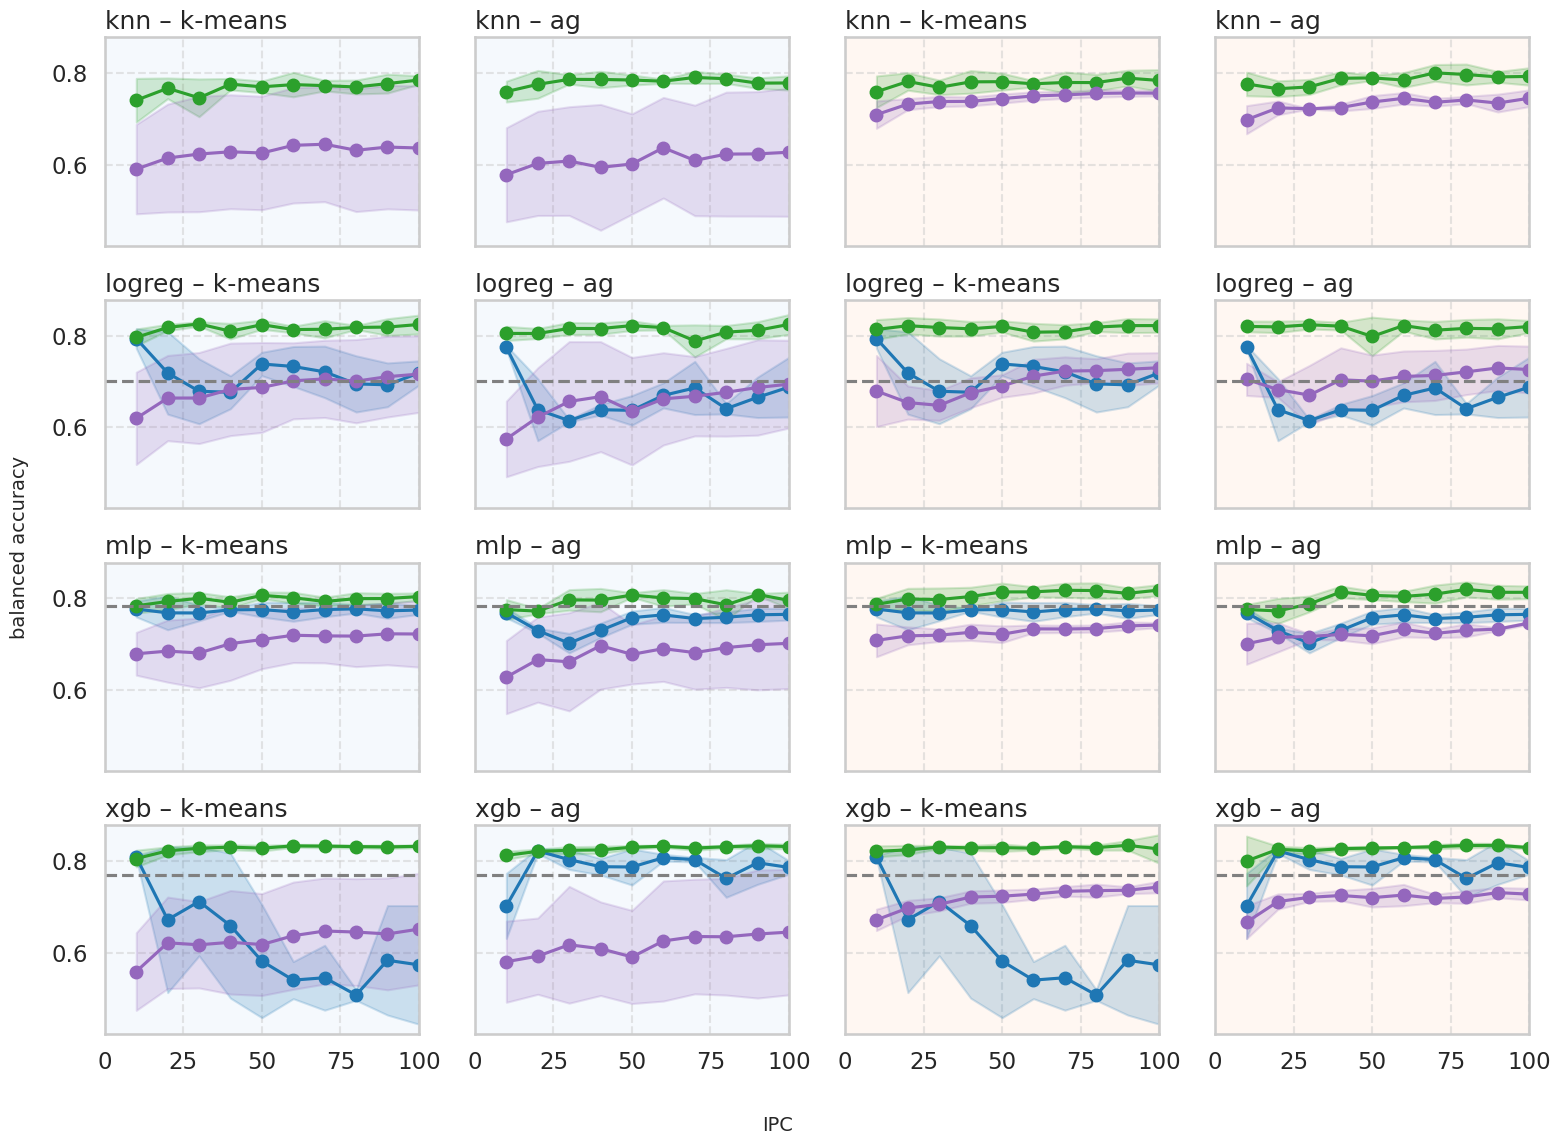

In [99]:
methods = ['k-means','ag']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_tdcoler_original_kg_test_balanced.png'
)

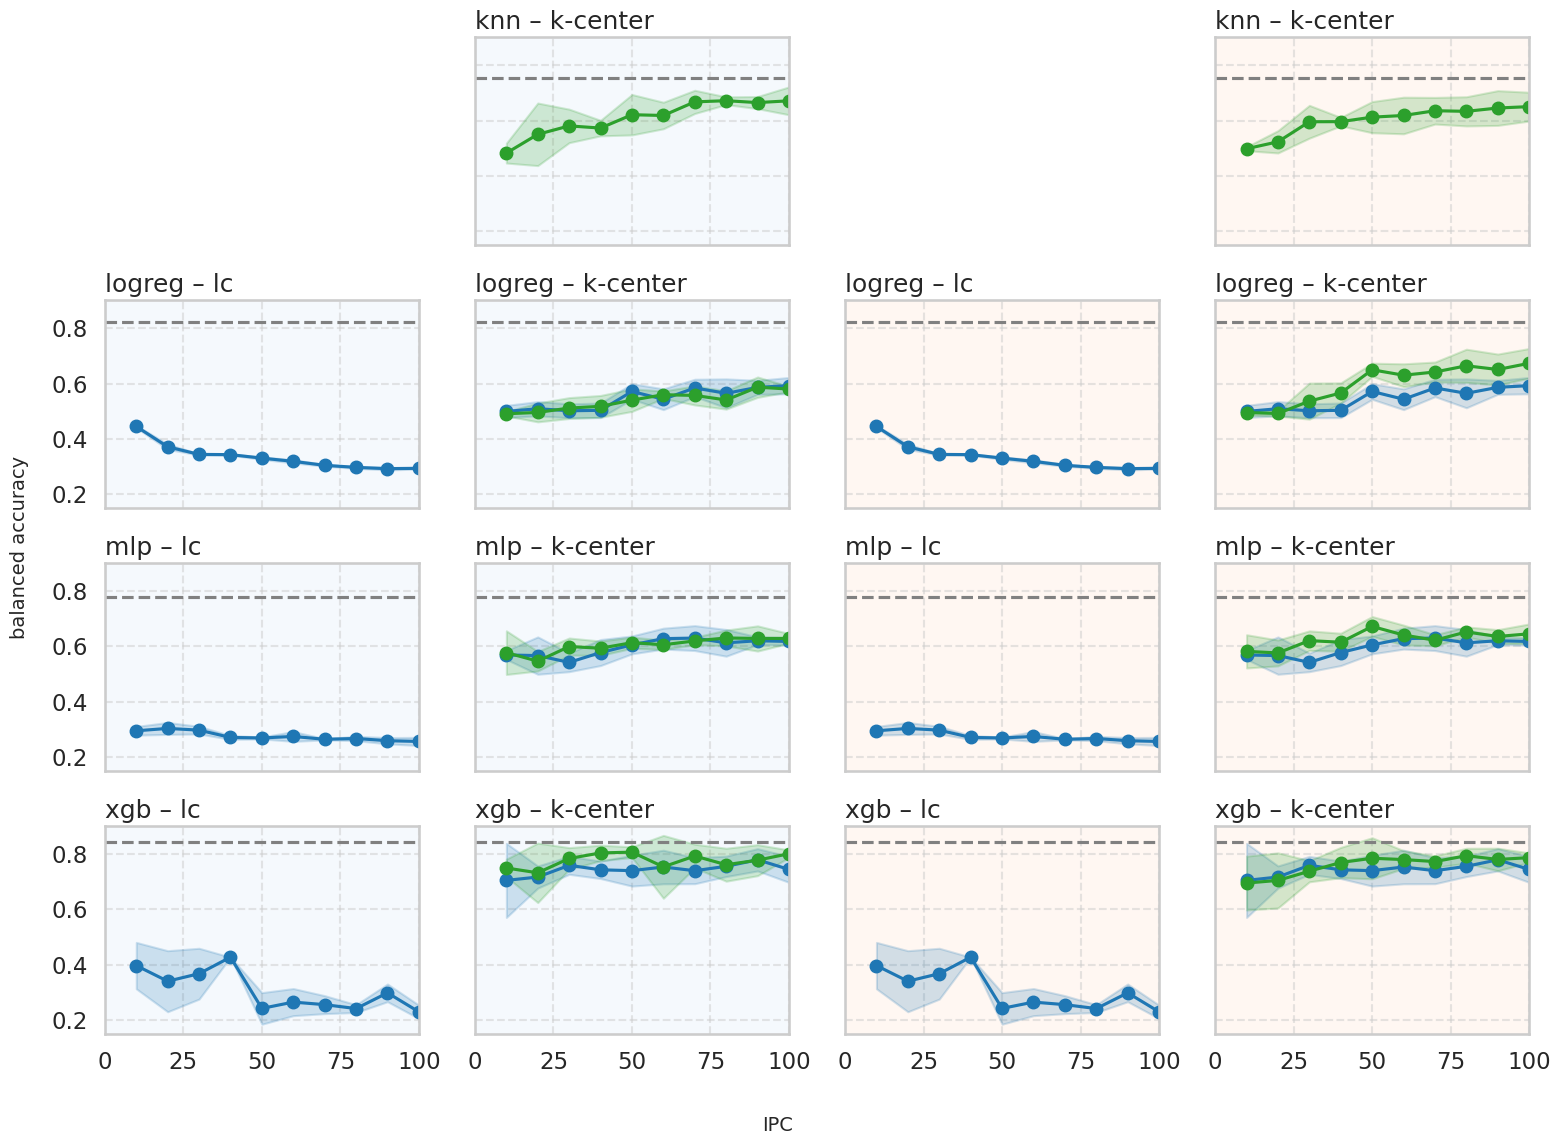

In [100]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_tdcoler_full_adult,
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_tdcoler_original_lck_test_balanced.png'
)

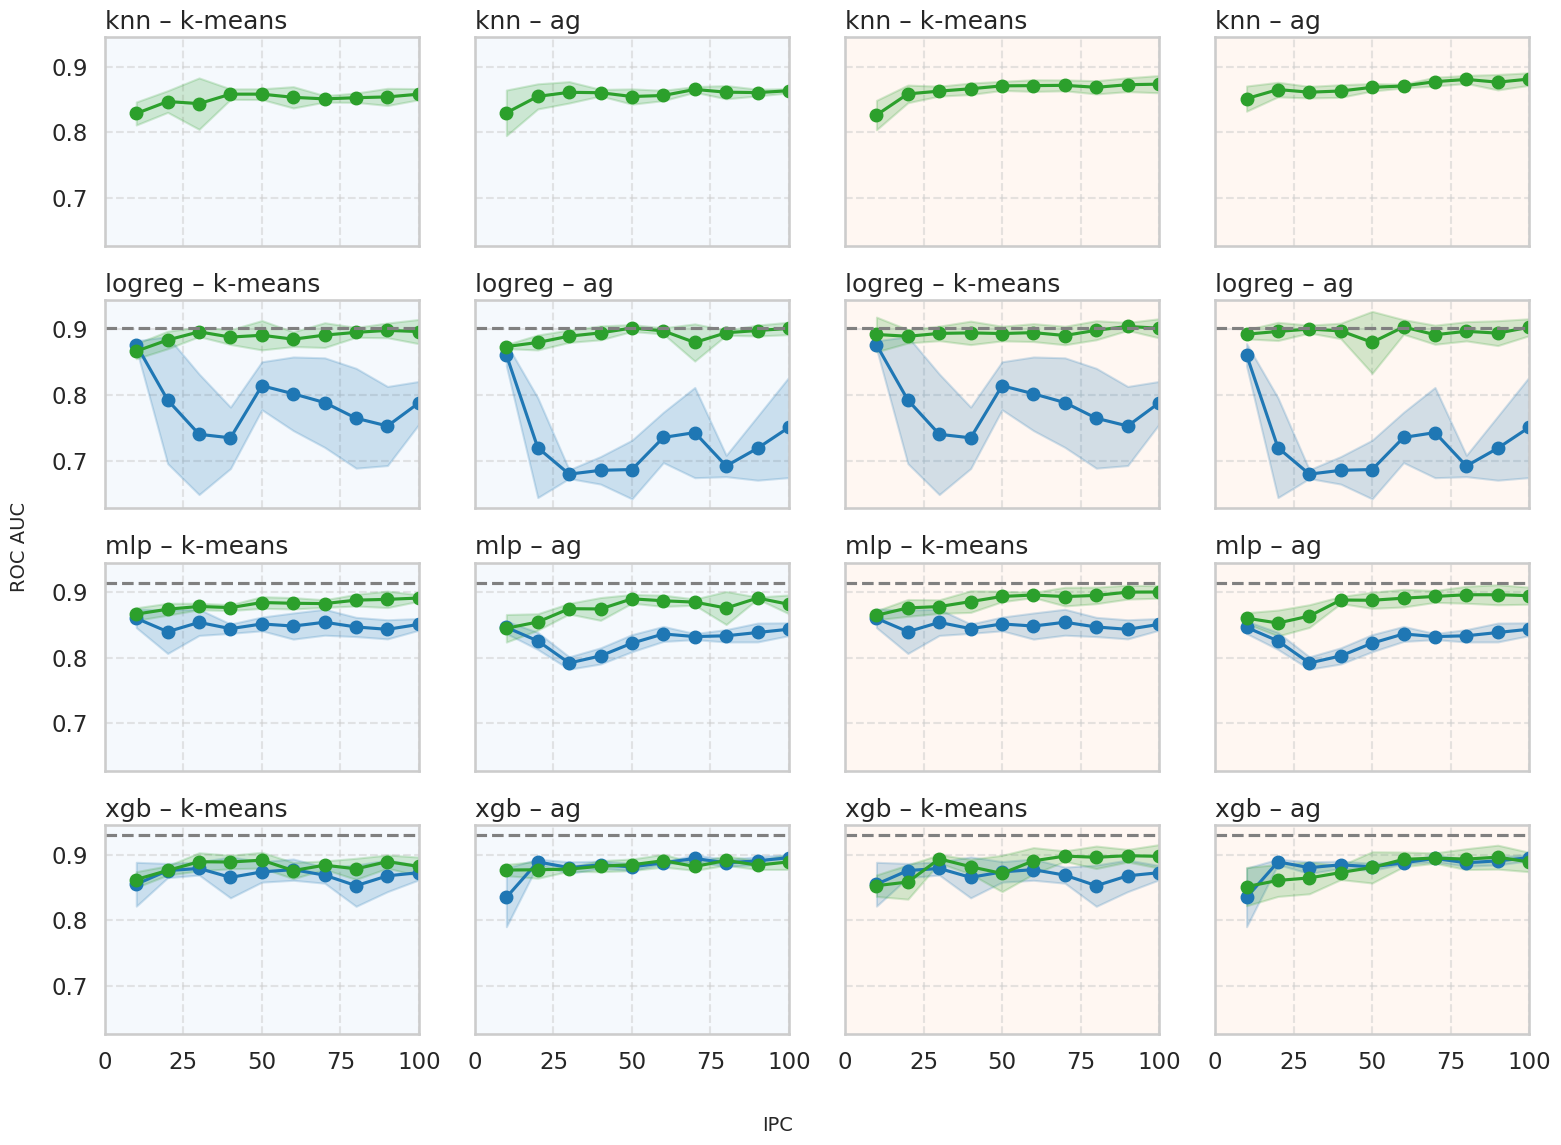

In [101]:
methods = ['k-means','ag']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_adult[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/adult_tdcoler_original_kg_roc_auc.png'
)

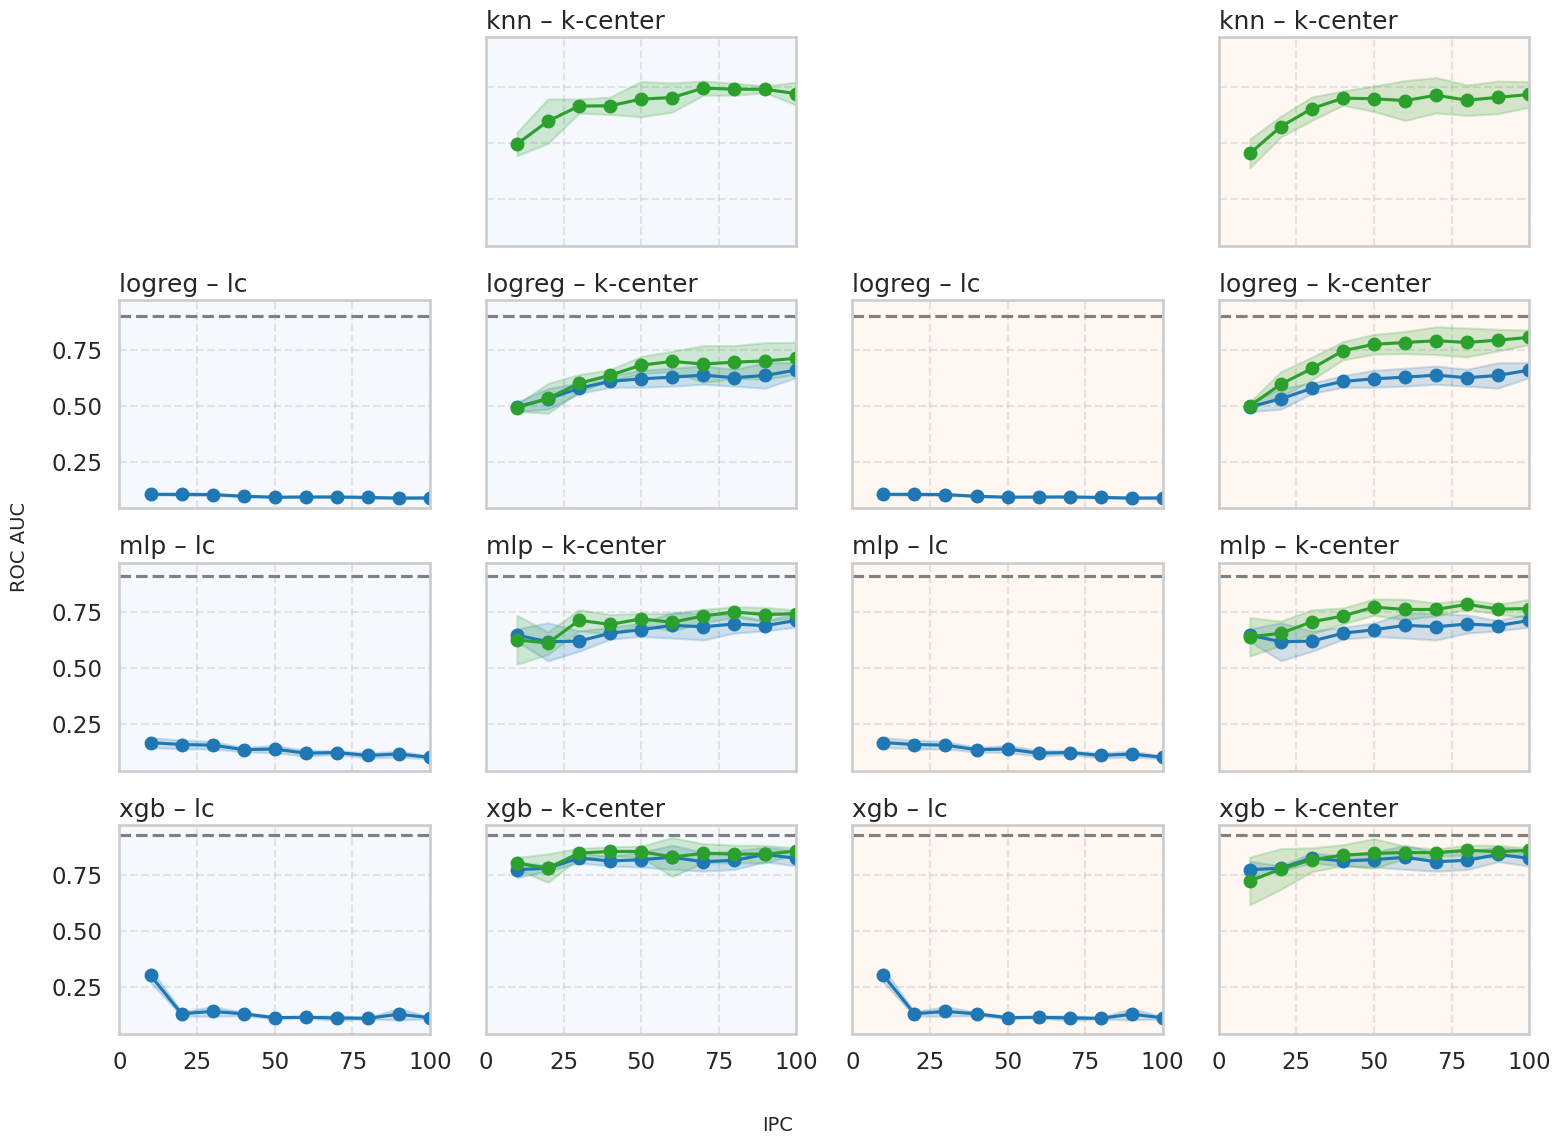

In [102]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_adult[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/adult_tdcoler_original_lck_roc_auc.png'
)

## Dataset Default

In [103]:
df_only_coreset_default = pd.read_csv('../BACKUP/Experiments_F_H/checkpoint_default_Doriginal_H/metrics.csv')
df_only_coreset_default['method'] = df_only_coreset_default['method'].replace(
     'k_center', 'k-center'
)
df_full_default = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_default = pd.read_csv('Experiments_K/checkpoint_default_Dlatent_G/metrics.csv')
df_latent_ft_default = pd.read_csv('Experiments_K/checkpoint_default_Dlatent_ft_H/metrics.csv')

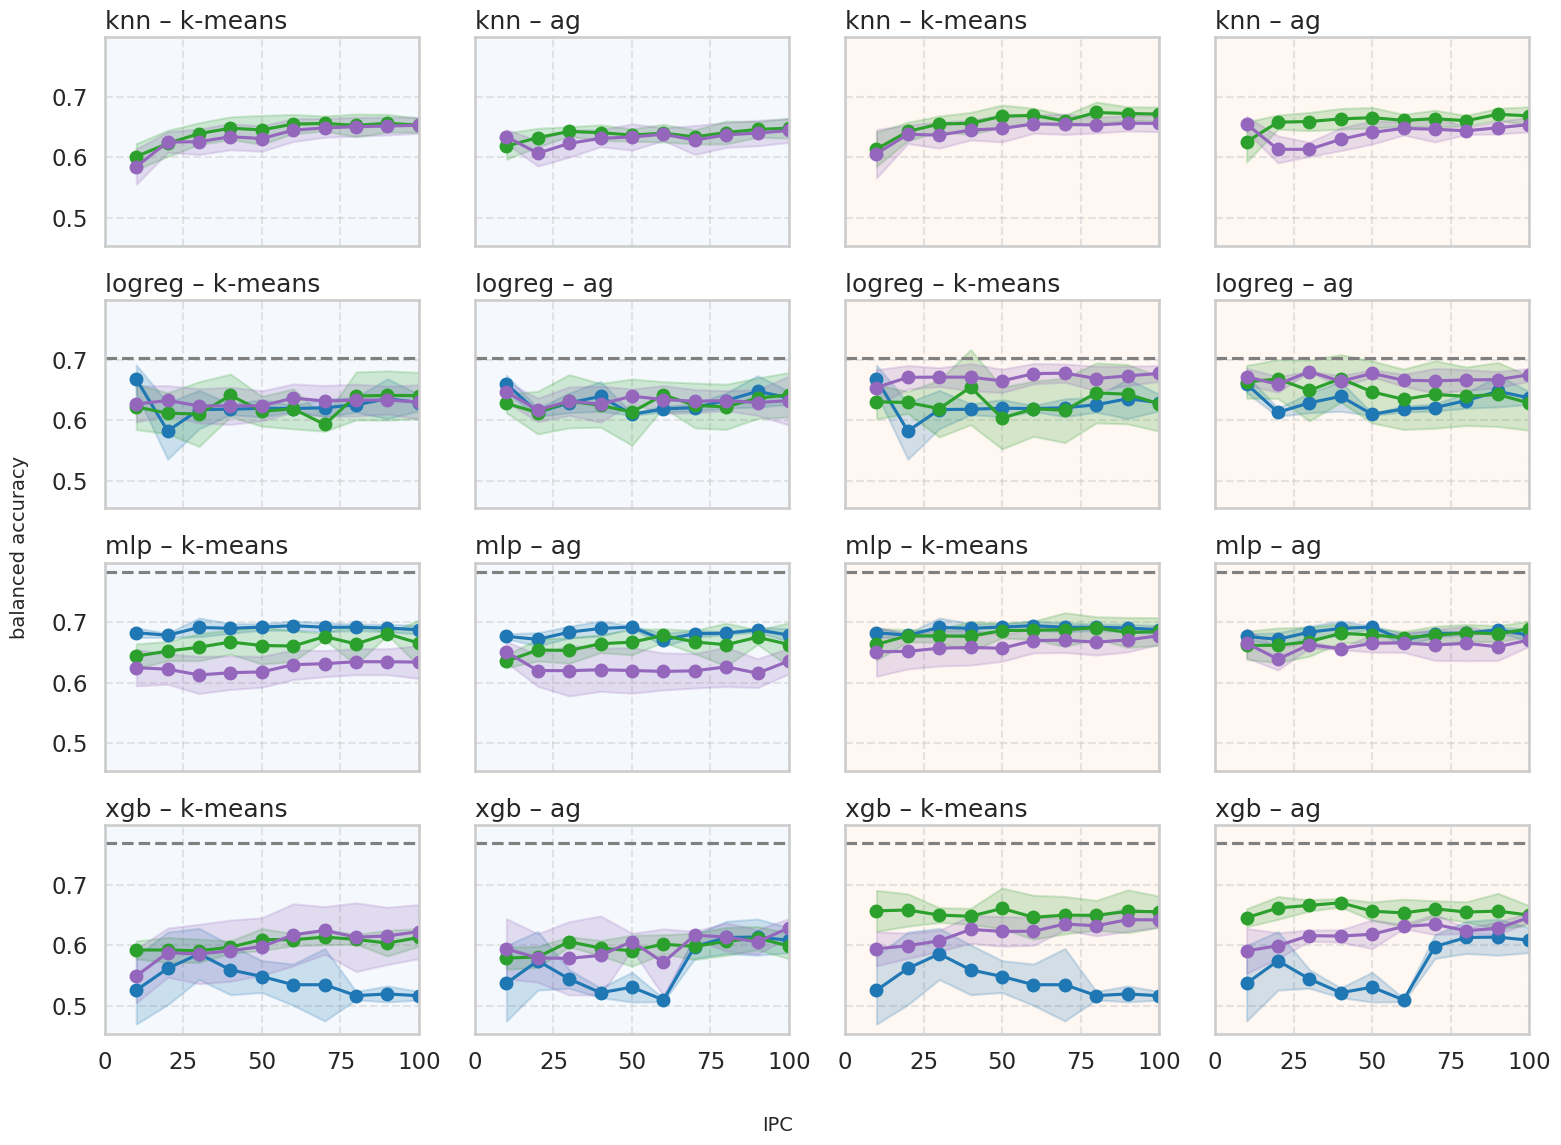

In [104]:
methods = ['k-means','ag']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_balanced']],
    df_latent=df_latent_default[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/default_tdcoler_original_kg_test_balanced.png'
)

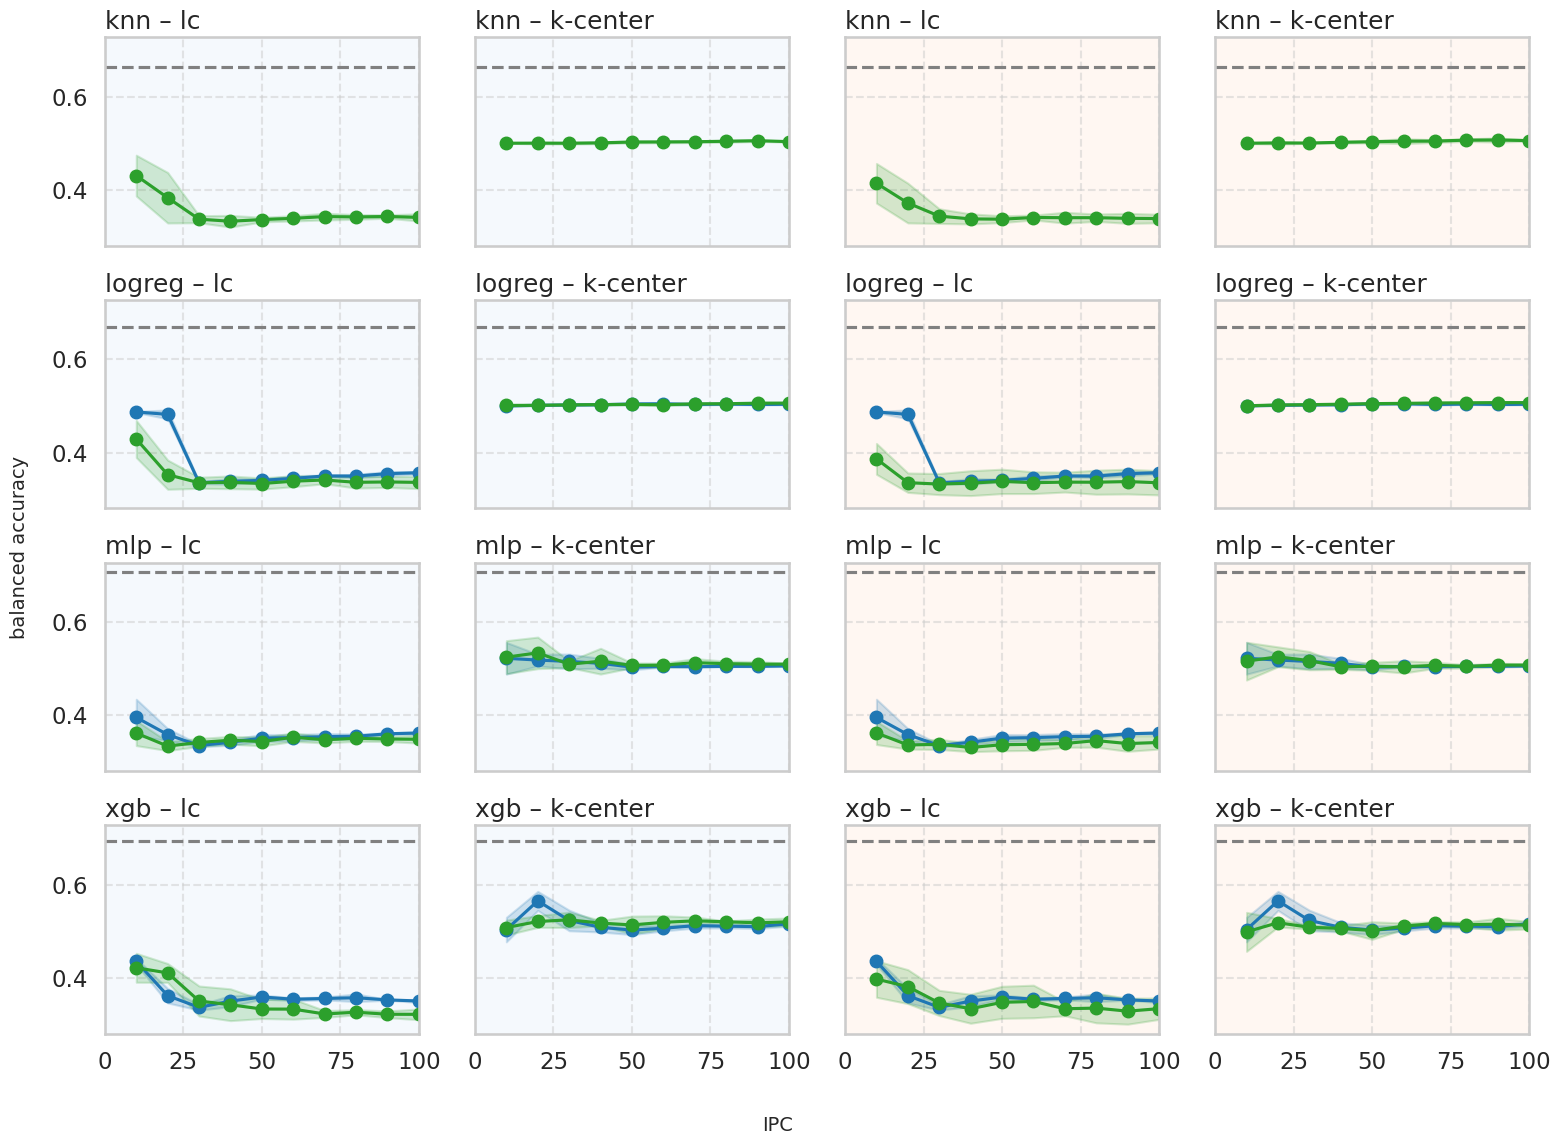

In [105]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_tdcoler_full_default,
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_balanced']],
    df_latent=df_latent_default[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/default_tdcoler_original_lck_test_balanced.png'
)

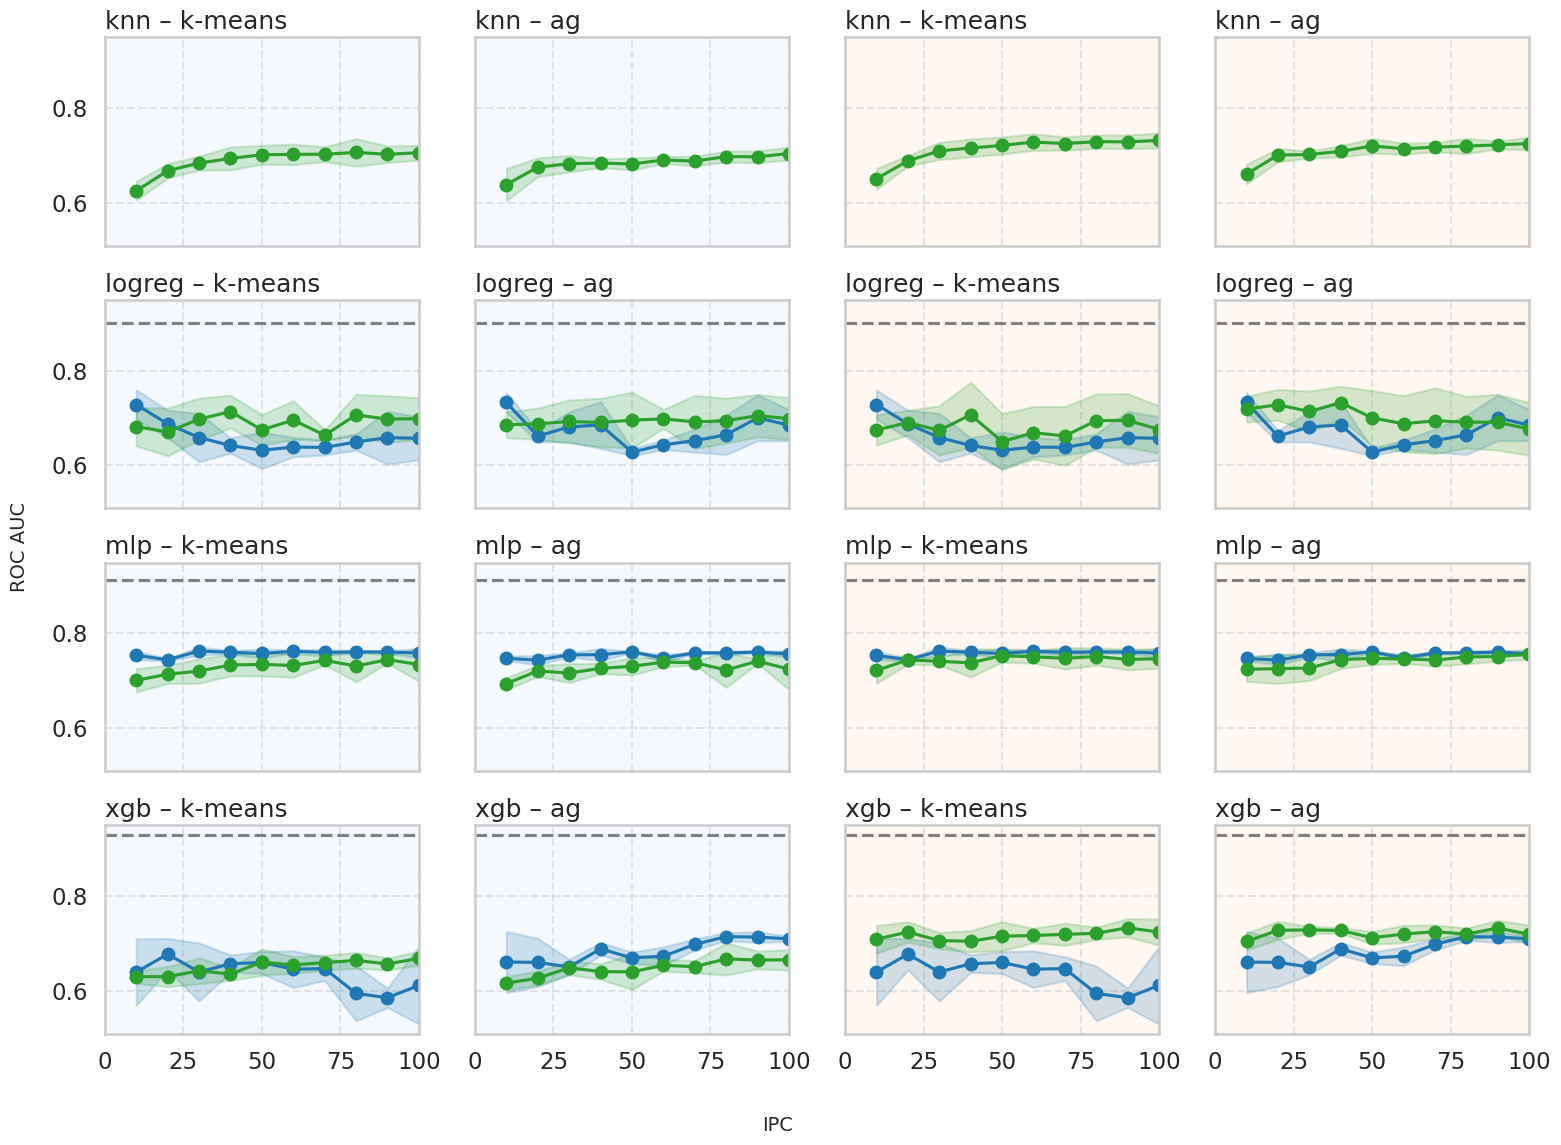

In [106]:
methods = ['k-means','ag']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_default[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/default_tdcoler_original_kg_roc_auc.png'
)

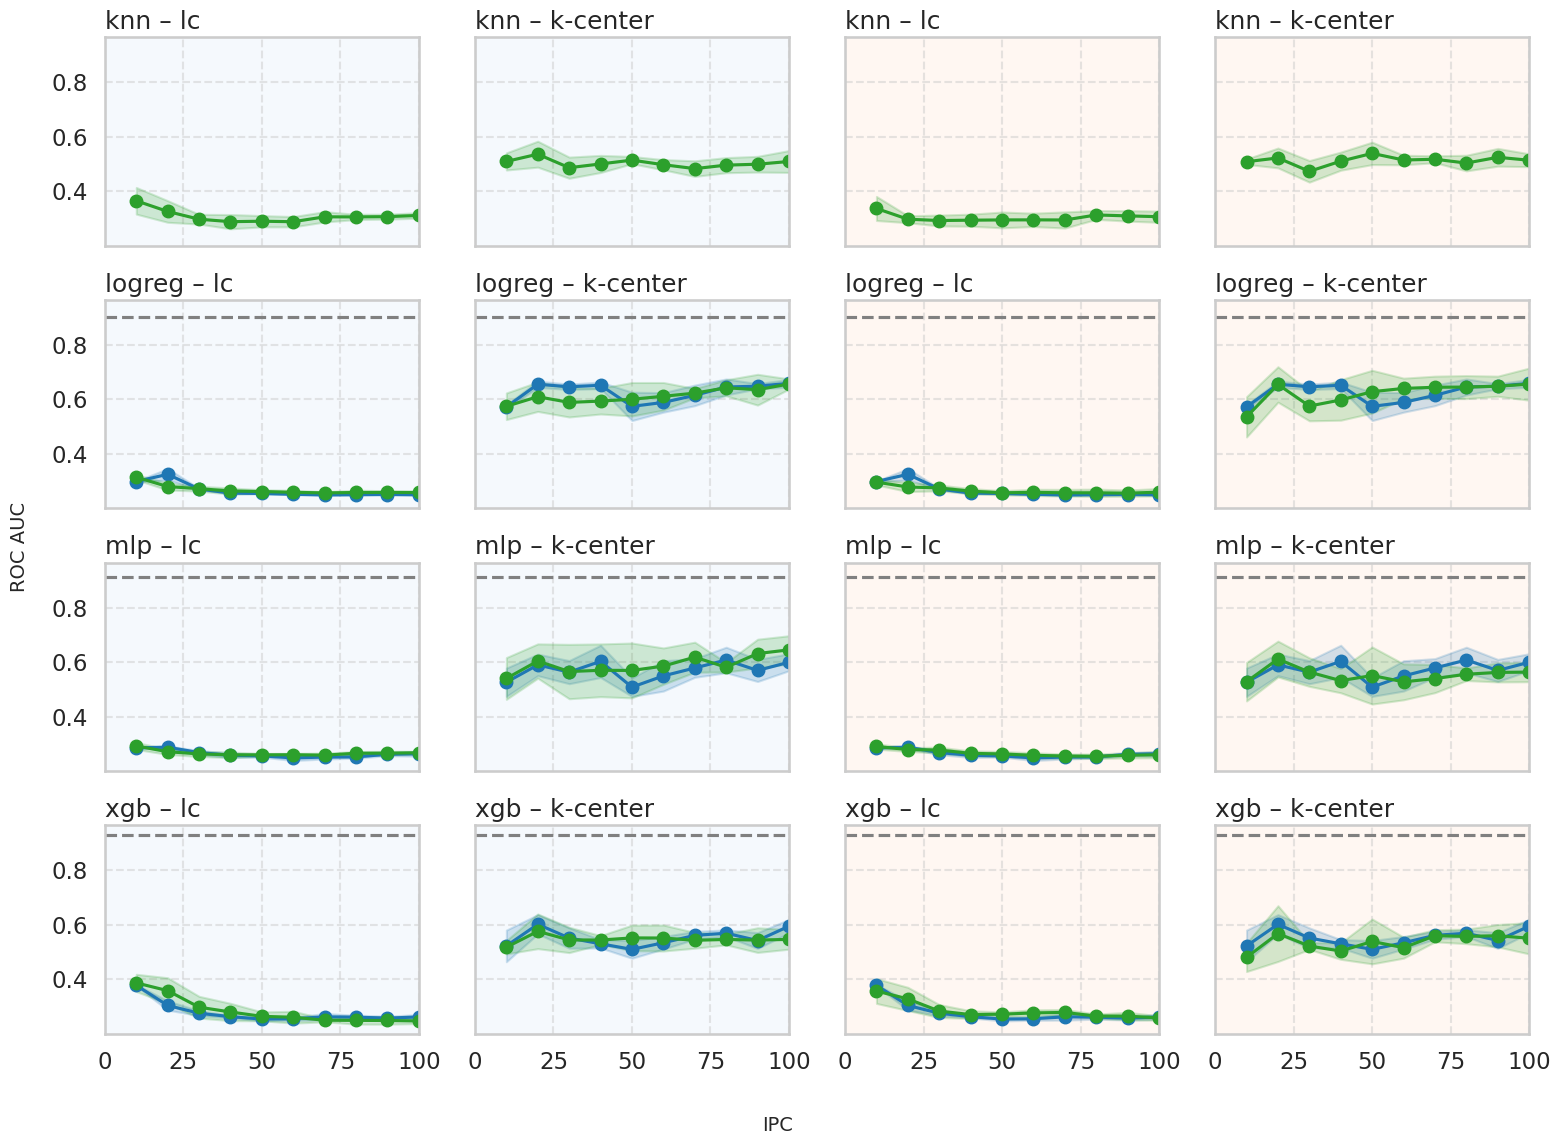

In [107]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_default[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/default_tdcoler_original_kg_roc_auc.png'
)

## Dataset shopper

In [113]:
df_only_coreset_shoppers = pd.read_csv('../BACKUP/Experiments_A/checkpoint_shoppers_Doriginal_Roriginal_A/metrics.csv')
df_only_coreset_shoppers['method'] = df_only_coreset_shoppers['method'].replace(
     'k_center', 'k-center'
)
df_full_shoppers = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_shoppers = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_F/metrics.csv')
df_latent_ft_shoppers = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_ft_F/metrics.csv')

In [ ]:
methods = ['k-means','ag']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_tdcoler_original_kg_roc_auc.png'
)

In [ ]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_shoppers,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_tdcoler_original_kg_roc_auc.png'
)